In [2]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [3]:
np.random.seed(42)


n = 500


data = pd.DataFrame({
'tenure': np.random.randint(1, 60, n),
'monthly_charges': np.random.randint(300, 1500, n),
'total_charges': np.random.randint(1000, 80000, n),
'support_calls': np.random.randint(0, 10, n),
'churn': np.random.choice([0, 1], size=n, p=[0.7, 0.3])
})


X = data.drop('churn', axis=1)
y = data['churn']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
pipeline = Pipeline([
('scaler', StandardScaler()),
('model', LogisticRegression())
])

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


cv_scores = cross_val_score(
pipeline,
X_train,
y_train,
cv=cv,
scoring='accuracy'
)


print("CV Accuracy per fold:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

CV Accuracy per fold: [0.7    0.7    0.7125 0.7125 0.7125]
Average CV Accuracy: 0.7074999999999999


In [7]:
pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)


print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.71
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        71
           1       0.00      0.00      0.00        29

    accuracy                           0.71       100
   macro avg       0.35      0.50      0.42       100
weighted avg       0.50      0.71      0.59       100



C:\Users\chawl\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\chawl\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\chawl\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

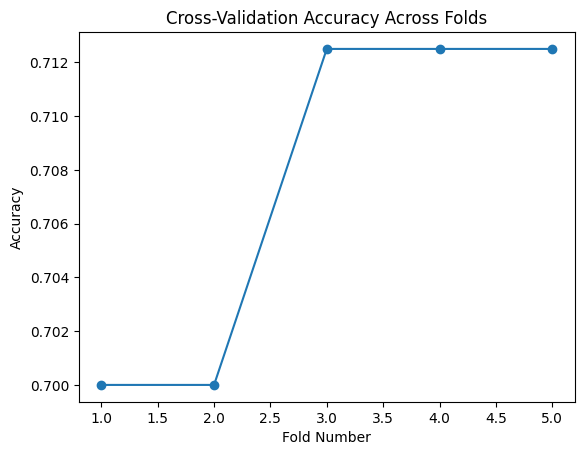

In [8]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy Across Folds')
plt.show()

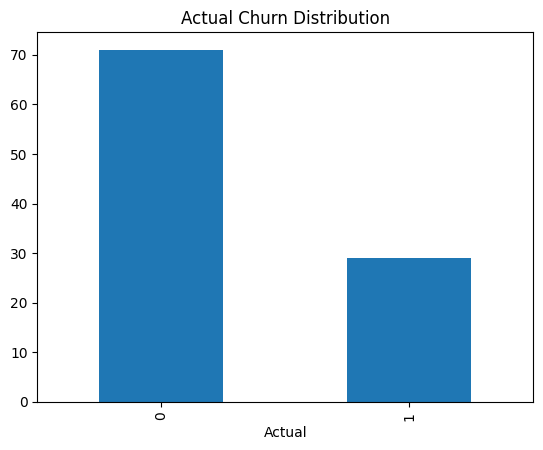

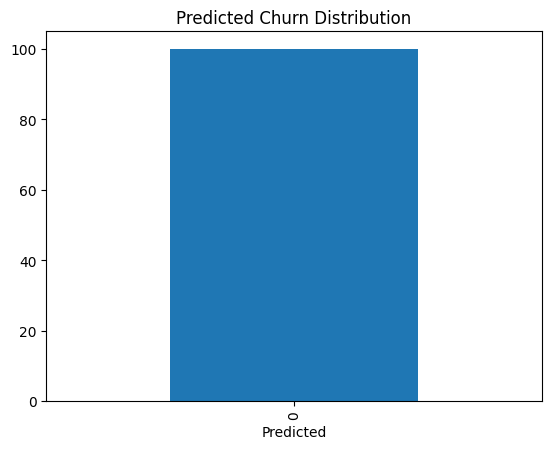

In [9]:
comparison = pd.DataFrame({
'Actual': y_test.values,
'Predicted': y_pred
})


comparison['Actual'].value_counts().plot(kind='bar')
plt.title('Actual Churn Distribution')
plt.show()


comparison['Predicted'].value_counts().plot(kind='bar')
plt.title('Predicted Churn Distribution')
plt.show()

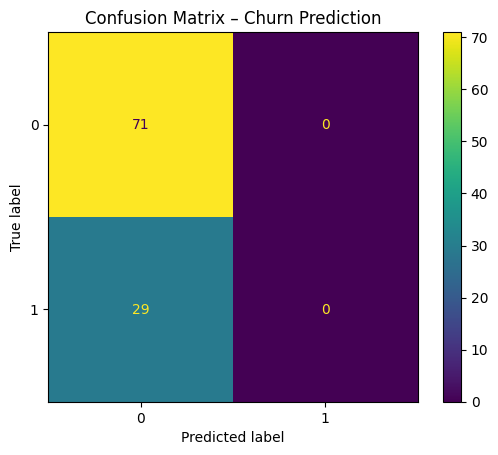

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_estimator(
pipeline,
X_test,
y_test
)
plt.title('Confusion Matrix – Churn Prediction')
plt.show()